## Objective
Analyze store-level sales data to understand trends, patterns, and factors influencing sales.

# Store Sales Analysis

## Dataset Overview
The dataset contains features like store information, promotions, holidays, and weekly sales data.

## Workflow
1. Load and explore the dataset
2. Preprocess the data
3. Perform exploratory data analysis
4. Apply statistical or ML models
5. Draw conclusions

In [ ]:
# Import necessary libraries
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

from google.colab import files

uploaded = files.upload()

Saving features.csv to features.csv


['.config', 'features.csv', 'sample_data']


Saving features.csv to features (1).csv
Uploaded File: features (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'

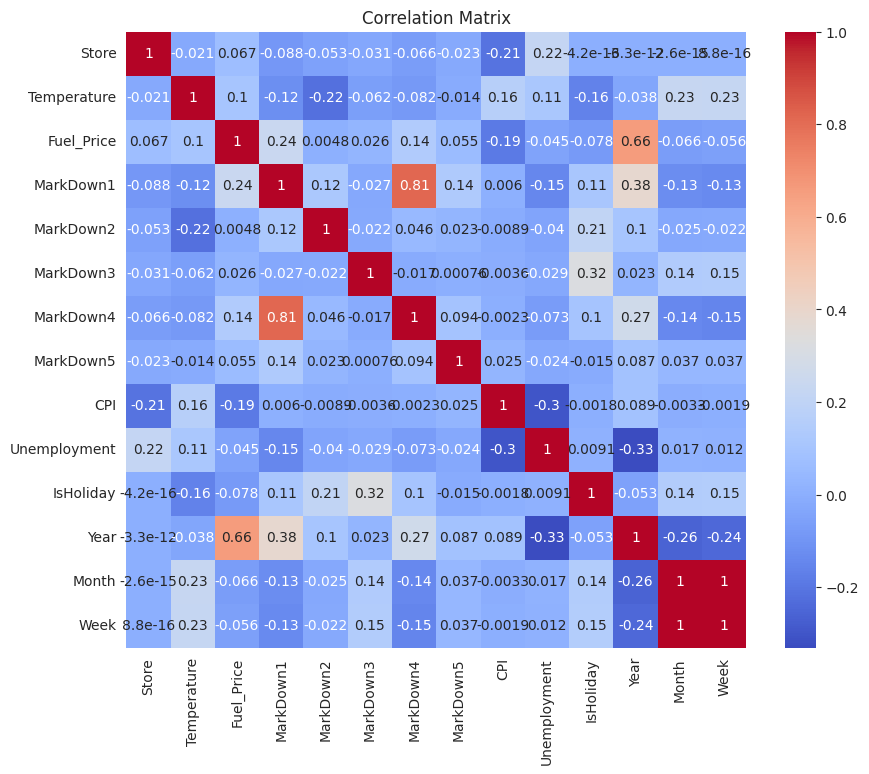

<Figure size 1500x600 with 0 Axes>

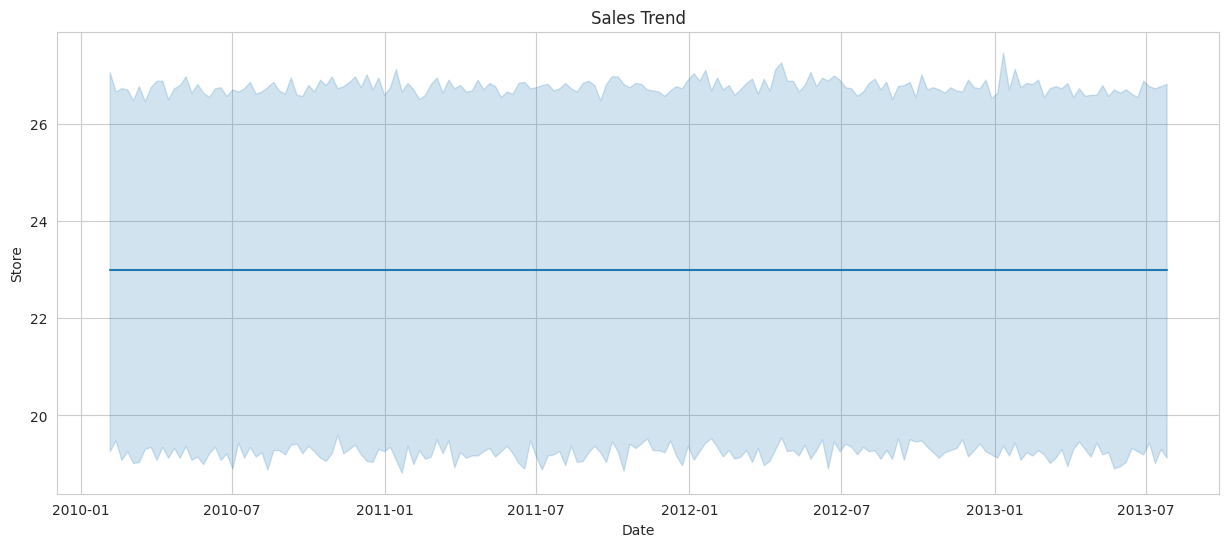

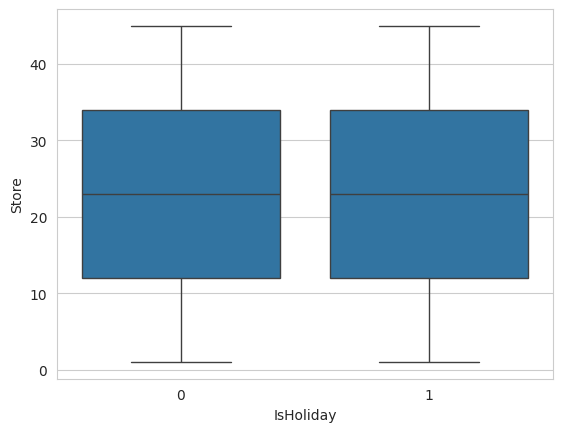

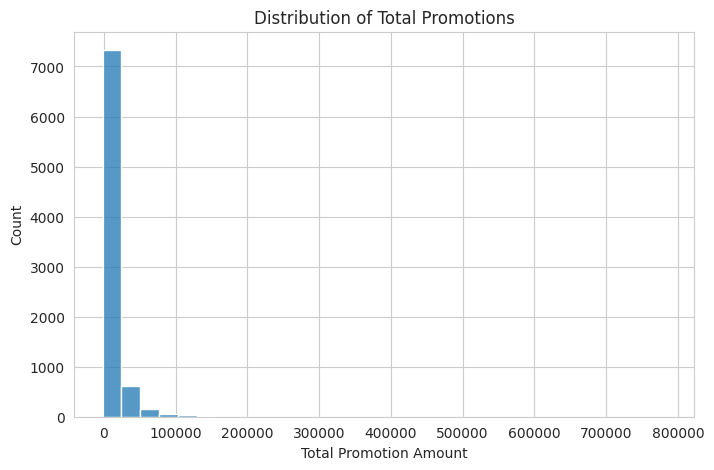

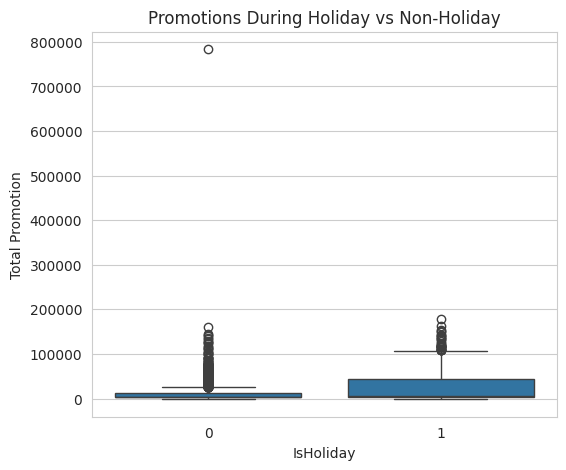

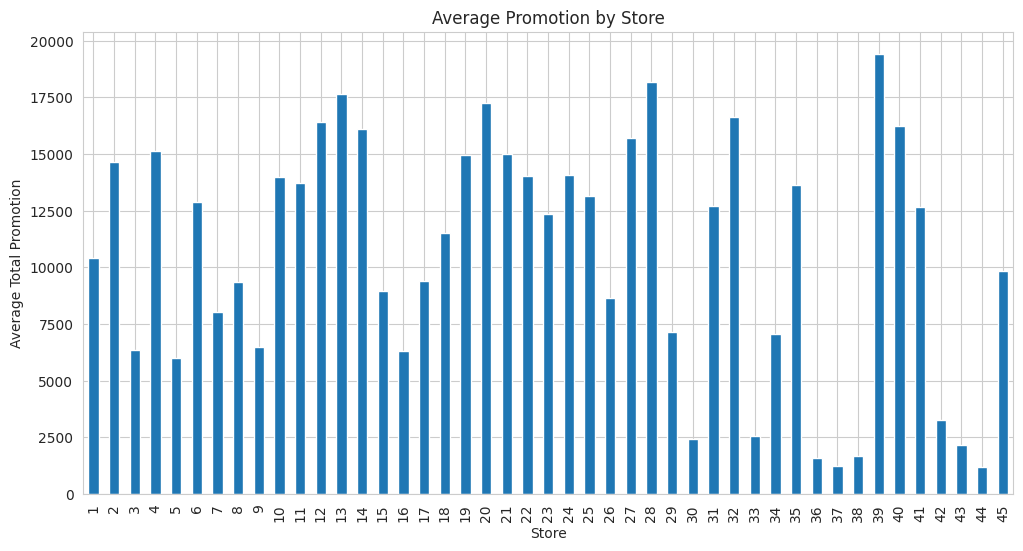

count    8190.000000
mean       59.356198
std        18.678607
min        -7.290000
25%        45.902500
50%        60.710000
75%        73.880000
max       101.950000
Name: Temperature, dtype: float64
0


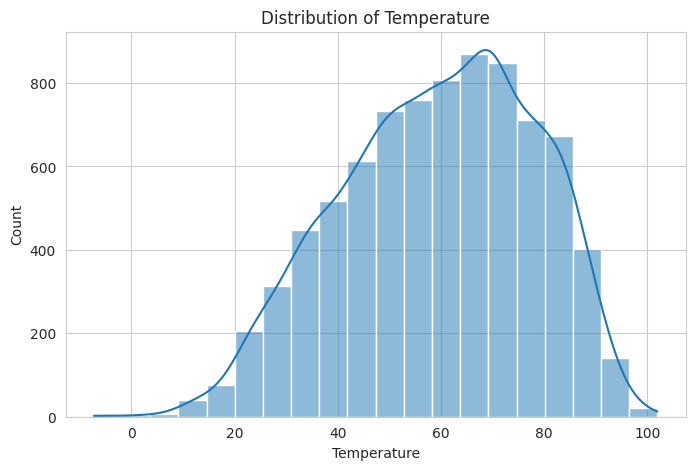

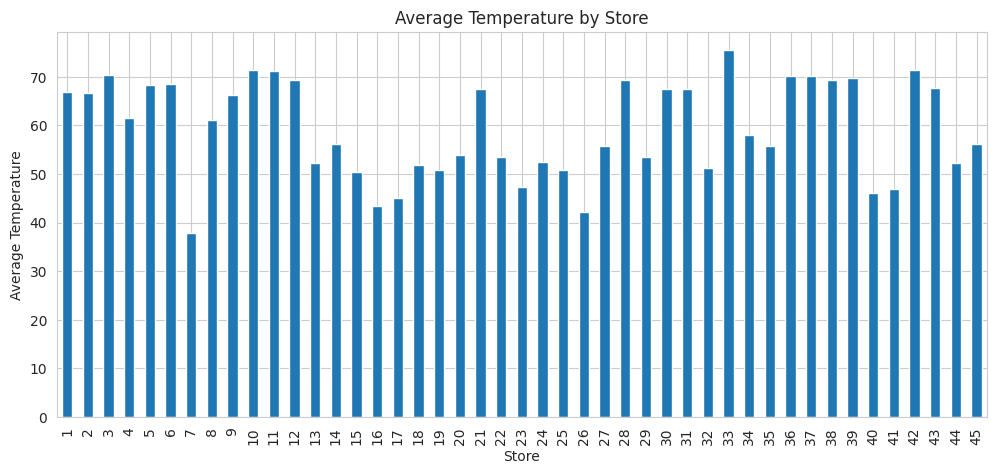

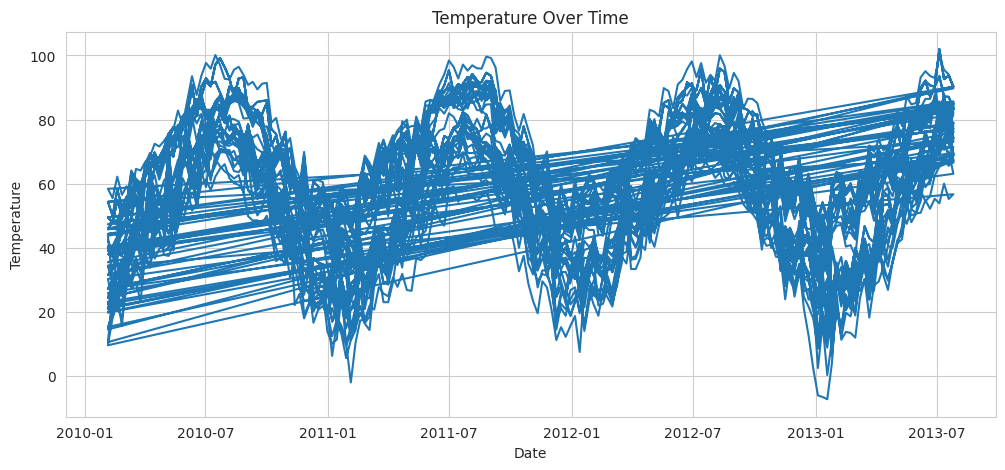

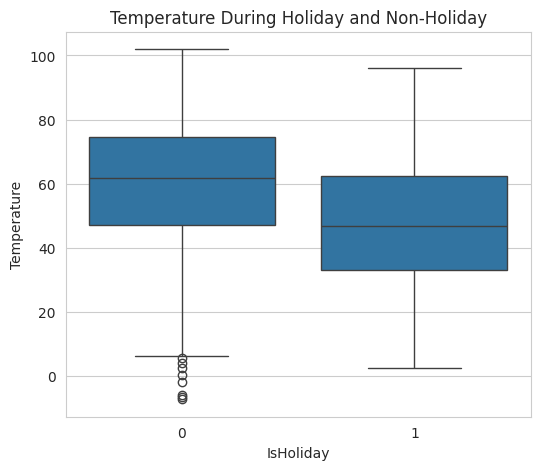

count    8190.000000
mean        3.405992
std         0.431337
min         2.472000
25%         3.041000
50%         3.513000
75%         3.743000
max         4.468000
Name: Fuel_Price, dtype: float64
0


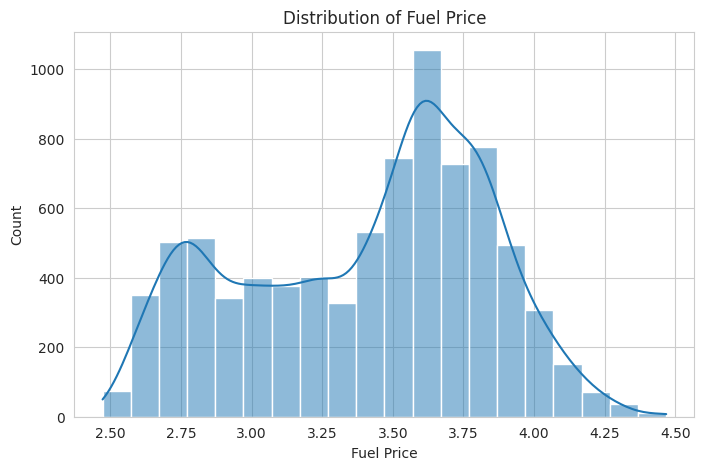

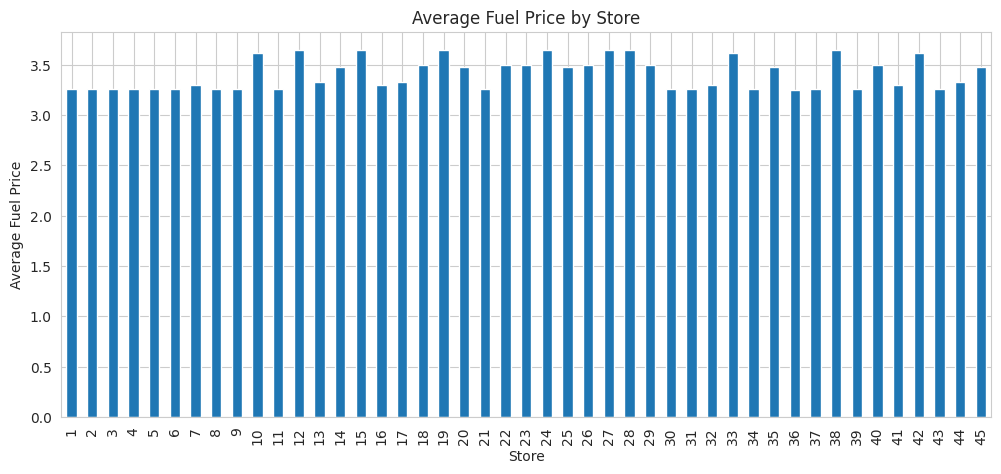

0
count    8190.000000
mean        7.747708
std         1.878347
min         3.684000
25%         6.565000
50%         7.742000
75%         8.549000
max        14.313000
Name: Unemployment, dtype: float64


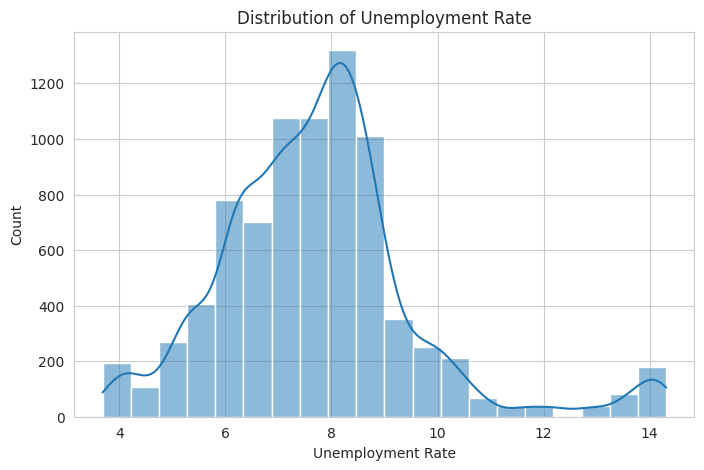

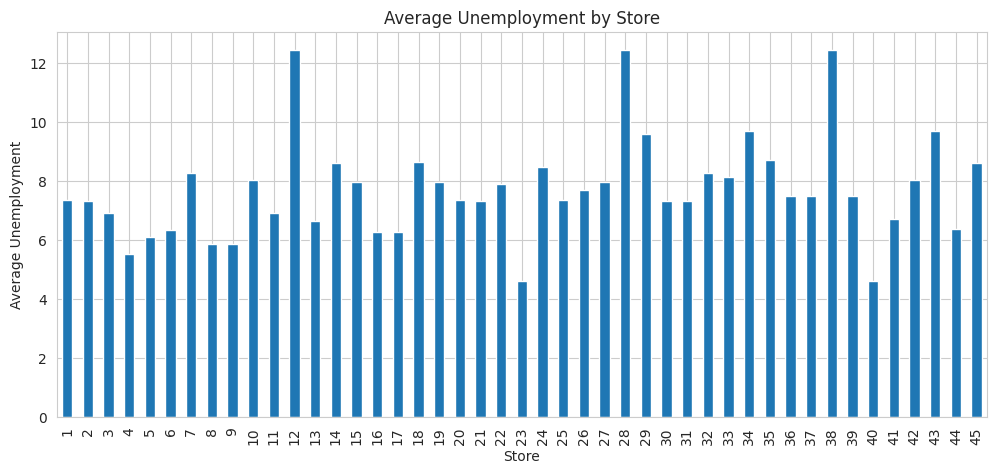

0
count    8190.000000
mean      172.855800
std        39.898285
min       126.064000
25%       132.653774
50%       182.855869
75%       214.367504
max       228.976456
Name: CPI, dtype: float64


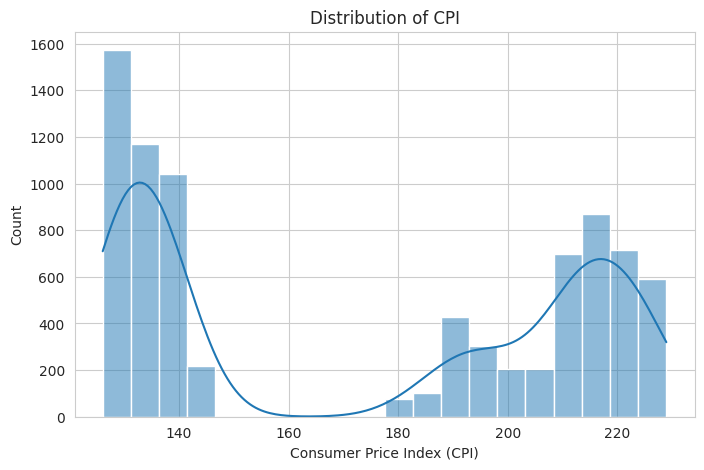

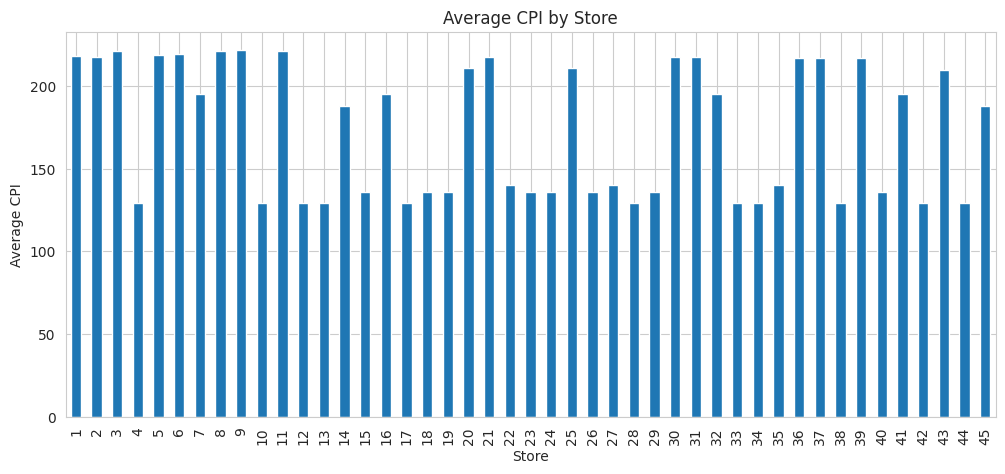

        Date  Year
0 2010-02-05  2010
1 2010-02-12  2010
2 2010-02-19  2010
3 2010-02-26  2010
4 2010-03-05  2010
        Date Month_Name
0 2010-02-05   February
1 2010-02-12   February
2 2010-02-19   February
3 2010-02-26   February
4 2010-03-05      March


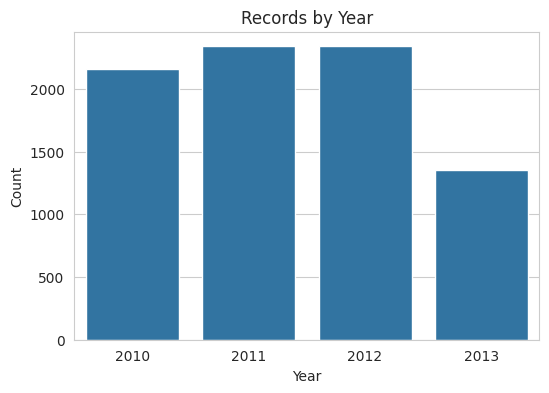

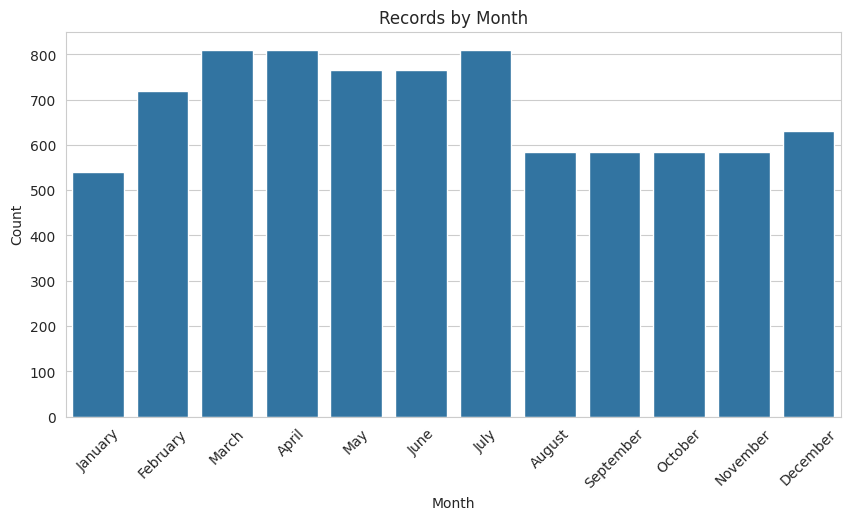

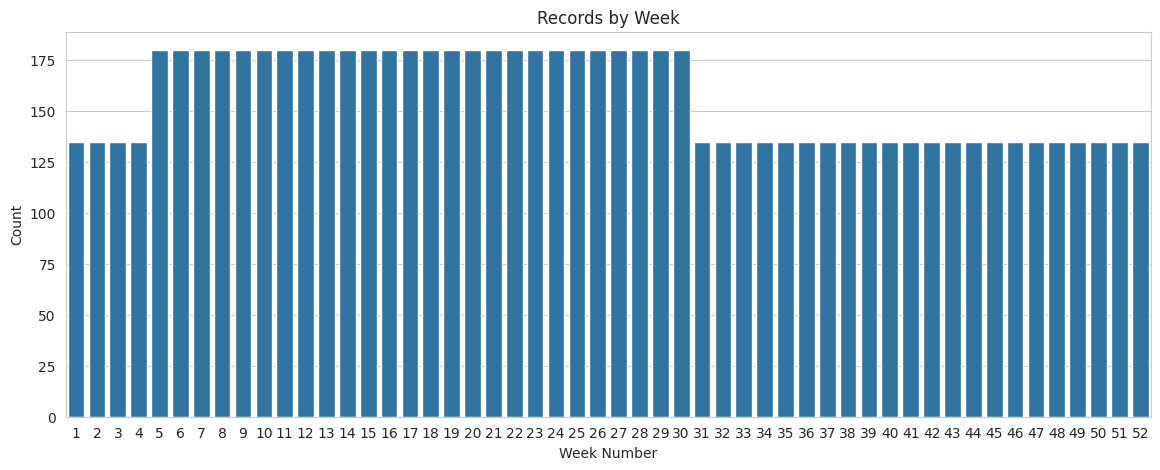

In [ ]:
# Load the dataset
df = pd.read_csv("features.csv")

import os

print(os.listdir())

from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

# Automatically read the uploaded CSV
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Uploaded File:", filename)
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.fillna(method='ffill', inplace=True)
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['IsHoliday'] = df['IsHoliday'].astype(int)

print(df.columns)

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()
plt.figure(figsize=(15,6))

plt.figure(figsize=(15,6))

sns.lineplot(data=df, x='Date', y='Store')

plt.title("Sales Trend")
plt.show()

sns.boxplot(x='IsHoliday', y='Store', data=df)

plt.show()


markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

df[markdown_cols] = df[markdown_cols].fillna(0)

df['Total_MarkDown'] = (
    df['MarkDown1'] +
    df['MarkDown2'] +
    df['MarkDown3'] +
    df['MarkDown4'] +
    df['MarkDown5']
)

df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','Total_MarkDown']].head()


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Total_MarkDown'], bins=30)
plt.title("Distribution of Total Promotions")
plt.xlabel("Total Promotion Amount")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(x='IsHoliday', y='Total_MarkDown', data=df)
plt.title("Promotions During Holiday vs Non-Holiday")
plt.xlabel("IsHoliday")
plt.ylabel("Total Promotion")
plt.show()

store_promo = df.groupby('Store')['Total_MarkDown'].mean()

plt.figure(figsize=(12,6))
store_promo.plot(kind='bar')
plt.title("Average Promotion by Store")
plt.xlabel("Store")
plt.ylabel("Average Total Promotion")
plt.show()

print(df['Temperature'].describe())
print(df['Temperature'].isnull().sum())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Temperature'], bins=20, kde=True)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.show()

store_temp = df.groupby('Store')['Temperature'].mean()

plt.figure(figsize=(12,5))
store_temp.plot(kind='bar')

plt.title("Average Temperature by Store")
plt.xlabel("Store")
plt.ylabel("Average Temperature")
plt.show()

df['Date'] = pd.to_datetime(df['Date'])
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Temperature'])

plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(x='IsHoliday', y='Temperature', data=df)

plt.title("Temperature During Holiday and Non-Holiday")
plt.show()

print(df['Fuel_Price'].describe())
print(df['Fuel_Price'].isnull().sum())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Fuel_Price'], bins=20, kde=True)

plt.title("Distribution of Fuel Price")
plt.xlabel("Fuel Price")
plt.ylabel("Count")

plt.show()
fuel_store = df.groupby('Store')['Fuel_Price'].mean()

plt.figure(figsize=(12,5))
fuel_store.plot(kind='bar')

plt.title("Average Fuel Price by Store")
plt.xlabel("Store")
plt.ylabel("Average Fuel Price")

plt.show()

print(df['Unemployment'].isnull().sum())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].median())
print(df['Unemployment'].describe())
plt.figure(figsize=(8,5))

sns.histplot(df['Unemployment'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate")
plt.ylabel("Count")

plt.show()
unemployment_store = df.groupby('Store')['Unemployment'].mean()

plt.figure(figsize=(12,5))
unemployment_store.plot(kind='bar')

plt.title("Average Unemployment by Store")
plt.xlabel("Store")
plt.ylabel("Average Unemployment")

plt.show()

print(df['CPI'].isnull().sum())
df['CPI'] = df['CPI'].fillna(df['CPI'].median())
print(df['CPI'].describe())
plt.figure(figsize=(8,5))

sns.histplot(df['CPI'], bins=20, kde=True)

plt.title("Distribution of CPI")
plt.xlabel("Consumer Price Index (CPI)")
plt.ylabel("Count")

plt.show()
cpi_store = df.groupby('Store')['CPI'].mean()

plt.figure(figsize=(12,5))
cpi_store.plot(kind='bar')

plt.title("Average CPI by Store")
plt.xlabel("Store")
plt.ylabel("Average CPI")

plt.show()

import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

print(df[['Date', 'Year']].head())
df['Month'] = df['Date'].dt.month

#print(df[['Date', 'Month']].head())
df['Month_Name'] = df['Date'].dt.month_name()

print(df[['Date', 'Month_Name']].head())
df[['Date', 'Year', 'Month', 'Month_Name', 'Week']].head(10)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Year', data=df)

plt.title("Records by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(10,5))
sns.countplot(x='Month_Name', data=df,
              order=['January','February','March','April','May','June',
                     'July','August','September','October','November','December'])

plt.xticks(rotation=45)
plt.title("Records by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(14,5))
sns.countplot(x='Week', data=df)

plt.title("Records by Week")
plt.xlabel("Week Number")
plt.ylabel("Count")
plt.show()



## Data Preprocessing
- Convert date to datetime
- Handle missing values
- Encode categorical variables

In [ ]:
# Convert 'Date' to datetime

import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].head())

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

df[['Date','Year','Month','Week']].head()

# Fill or drop missing values based on context

df.isnull().sum()
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

df[markdown_cols] = df[markdown_cols].fillna(0)
df.isnull().sum()
#IsHoliday
df['IsHoliday'] = df['IsHoliday'].astype(int)

df[['IsHoliday']].head()
df.dtypes
df.head()

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Week,Total_MarkDown,Month_Name
0,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,2010,2,5,0.0,February
1,1,2010-02-12,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,1,2010,2,6,0.0,February
2,1,2010-02-19,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,2010,2,7,0.0,February
3,1,2010-02-26,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,2010,2,8,0.0,February
4,1,2010-03-05,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,2010,3,9,0.0,March


## Exploratory Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Store           8190 non-null   int64         
 1   Date            8190 non-null   datetime64[ns]
 2   Temperature     8190 non-null   float64       
 3   Fuel_Price      8190 non-null   float64       
 4   MarkDown1       8190 non-null   float64       
 5   MarkDown2       8190 non-null   float64       
 6   MarkDown3       8190 non-null   float64       
 7   MarkDown4       8190 non-null   float64       
 8   MarkDown5       8190 non-null   float64       
 9   CPI             8190 non-null   float64       
 10  Unemployment    8190 non-null   float64       
 11  IsHoliday       8190 non-null   int64         
 12  Year            8190 non-null   int32         
 13  Month           8190 non-null   int32         
 14  Week            8190 non-null   UInt32        
 15  Tota

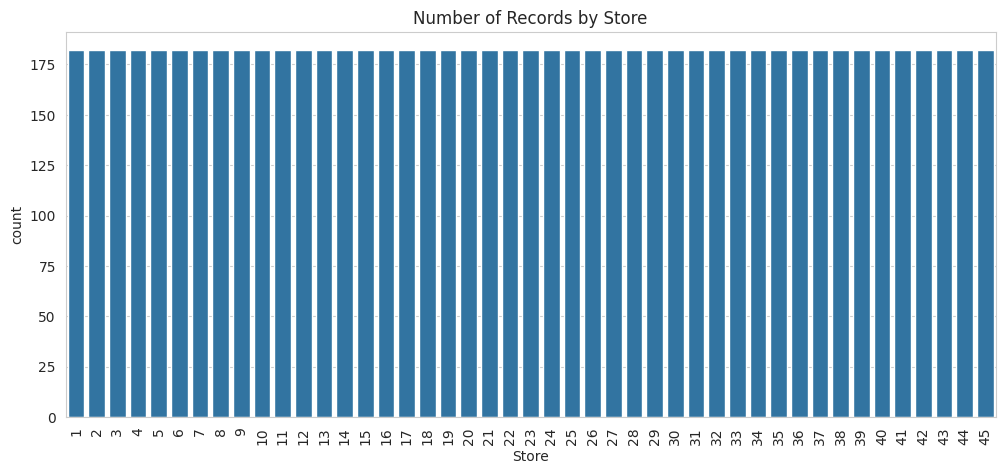

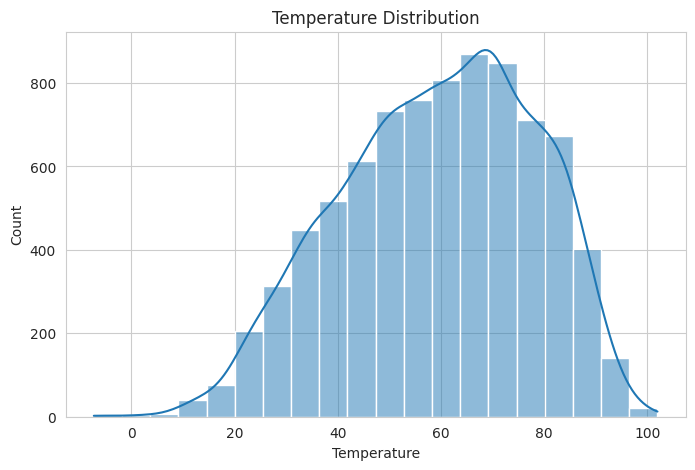

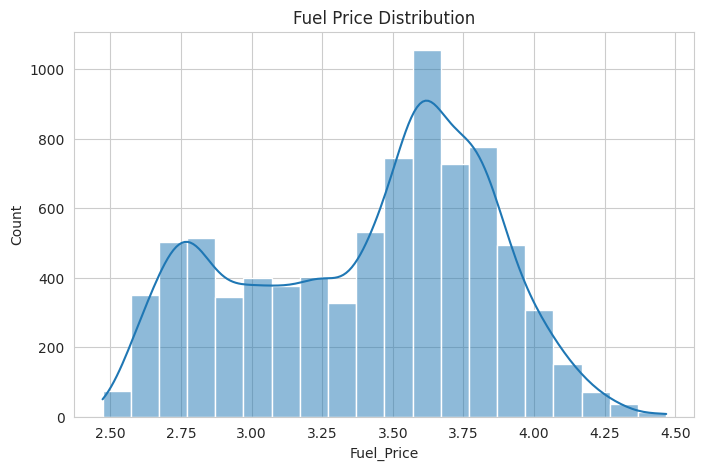

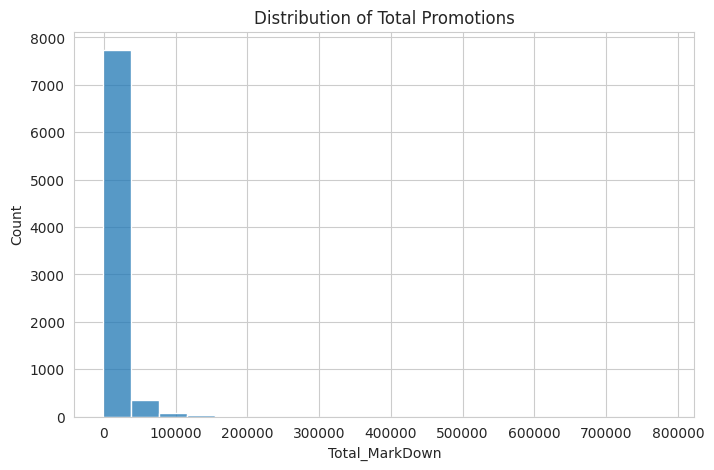

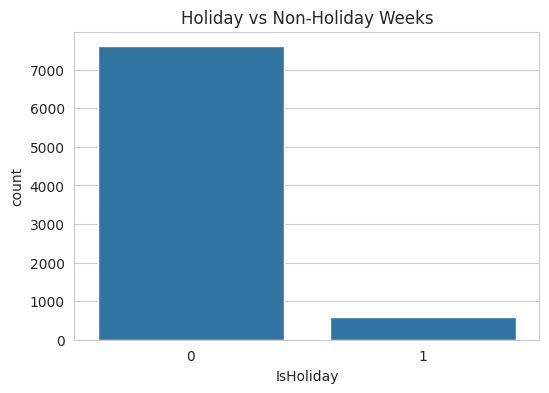

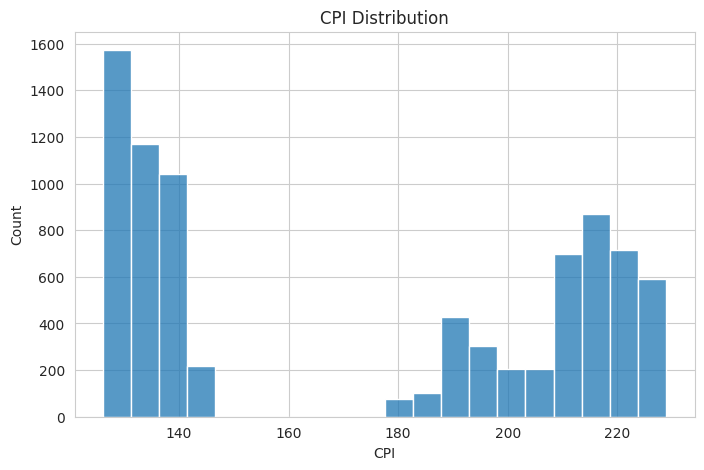

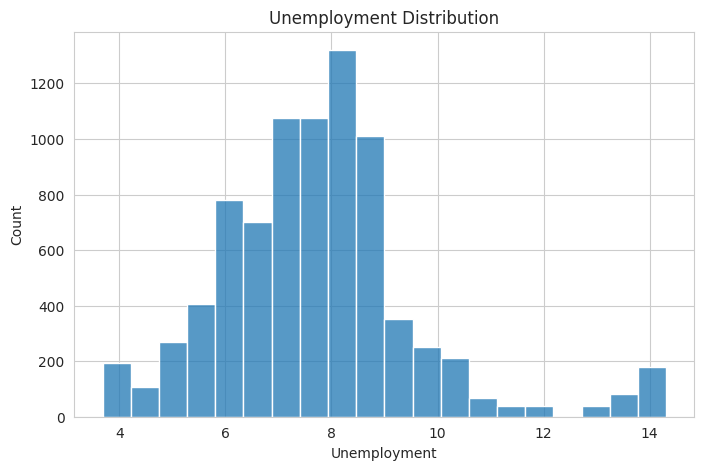

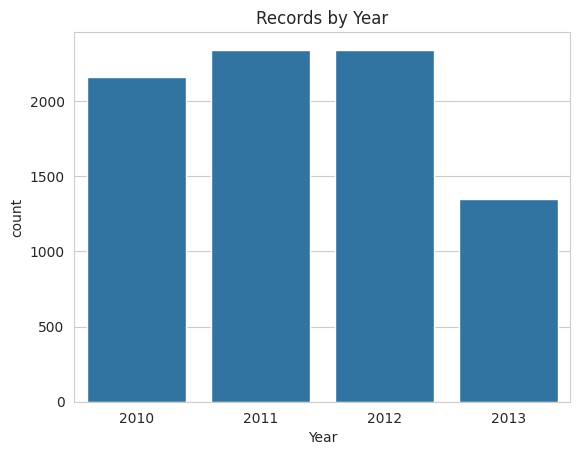

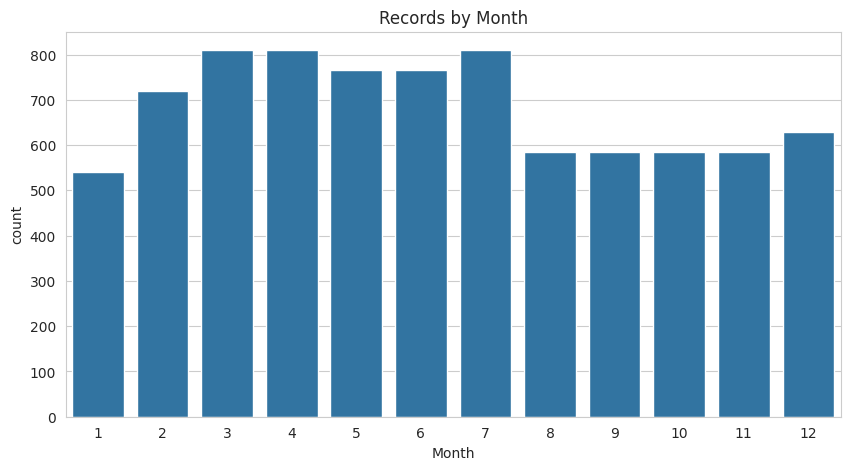

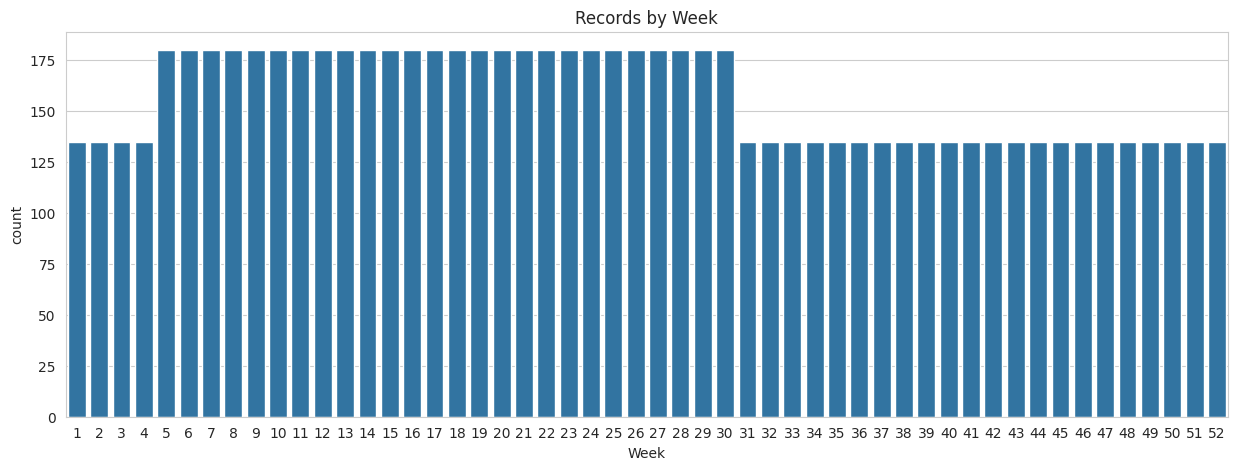

In [ ]:
# Weekly Sales distribution

df.head()
df.describe()
df.info()

#STORE ANALYSIS
plt.figure(figsize=(12,5))
sns.countplot(x='Store', data=df)

plt.title("Number of Records by Store")
plt.xticks(rotation=90)
plt.show()


#TEMPREATRE RECORD
plt.figure(figsize=(8,5))
sns.histplot(df['Temperature'], bins=20, kde=True)

plt.title("Temperature Distribution")
plt.show()

#FUEL PRICE ANALYSIS
plt.figure(figsize=(8,5))
sns.histplot(df['Fuel_Price'], bins=20, kde=True)

plt.title("Fuel Price Distribution")
plt.show()


#PROMOTION ANALYSIS
df['Total_MarkDown'] = (
    df['MarkDown1'] +
    df['MarkDown2'] +
    df['MarkDown3'] +
    df['MarkDown4'] +
    df['MarkDown5']
)
plt.figure(figsize=(8,5))
sns.histplot(df['Total_MarkDown'], bins=20)

plt.title("Distribution of Total Promotions")
plt.show()


#HOLIDAY ANALYSIS
plt.figure(figsize=(6,4))
sns.countplot(x='IsHoliday', data=df)

plt.title("Holiday vs Non-Holiday Weeks")
plt.show()


#CPI ANALYSIS
plt.figure(figsize=(8,5))
sns.histplot(df['CPI'], bins=20)

plt.title("CPI Distribution")
plt.show()


#UNEMPLOYMENT ANALYSIS
plt.figure(figsize=(8,5))
sns.histplot(df['Unemployment'], bins=20)

plt.title("Unemployment Distribution")
plt.show()



#DATE ANALYSIS
sns.countplot(x='Year', data=df)
plt.title("Records by Year")
plt.show()
plt.figure(figsize=(10,5))
sns.countplot(x='Month', data=df)

plt.title("Records by Month")
plt.show()
plt.figure(figsize=(15,5))
sns.countplot(x='Week', data=df)

plt.title("Records by Week")
plt.show()

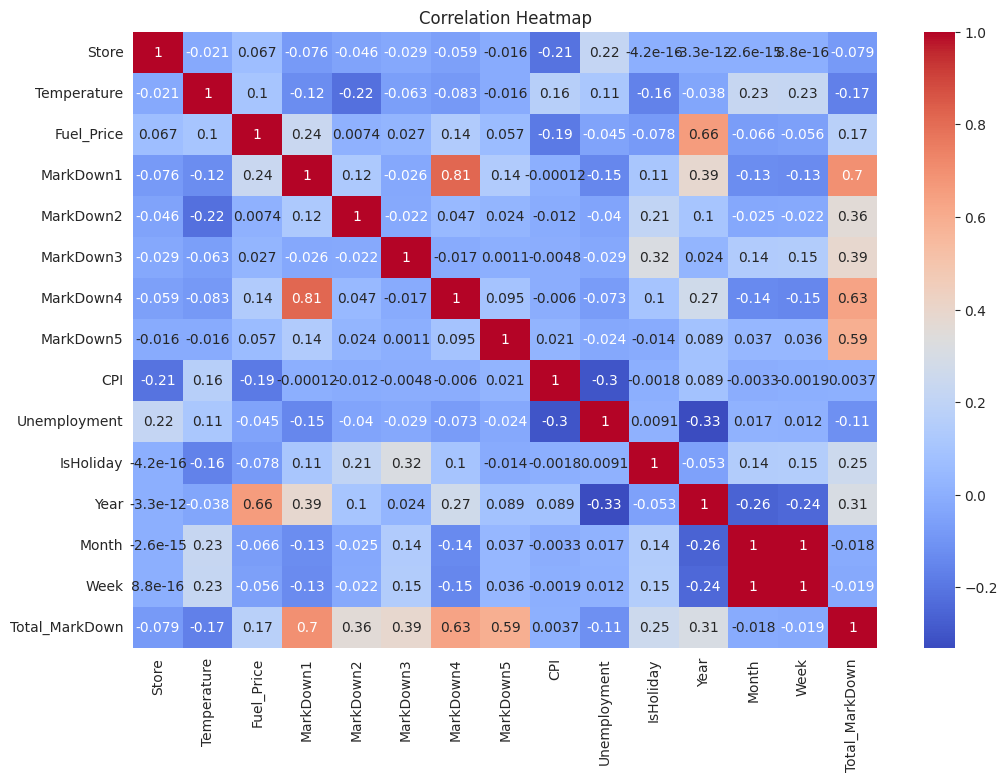

In [ ]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Model Training (if applicable)

In [ ]:
# Simple Linear Regression example if Weekly_Sales is present

THERE IS NO MODEL TRANING, BECAUSE DATA IS IN SIMPLE FORM THERE IS NO TARGET VALUES IS AVAILABLE INTO THE DATA FOR THE ANALYSIS. THE DATASET CONTAINS THE FEATURES LIKE TEMPERATURE,FUEL PRICE, ROMOTIONAL MARKDOWNS, ETC. WEEKLY_VALUES IS HOT PRESENT IN THE GIVEN DATA FOR THE MODEL TRANING CONCLUSION.

##Conclusion

This project analyzed the store-level data to understand different business factores such as tempreature, fuel price, promotional markdowns, CPI, unemployment and holiday periods. the dataset was cleaned by handeling the missing values, converting the date into the a proper datetime format, and preparing the data for analysis.

  The Exploratory Data Analysis(EDA) helped identify patterns and trends
in the data. it showed that promotional activities, economics, indicators and holiday periods varied across stores. These insights can help business understand operational conditions and support better planning.

  Since the dataset does not include the Weekly sales columns, sales predictions and amchine learning model tranning colud not be performed. Therefore, the project focused on understanding the available data and extracting meaningful business insights.

Overall, this analysis provides a clear understanding of the dataset and demonstrates how data preprocessing and visualization can help business make informed decisions. In the future, if sales data is available, predictive models can be developed to forecast sales and improve business performance.

